# Aula 2: Experimentação e MVP de Modelos - Heart Disease Dataset

## Objetivos de Aprendizagem
- Realizar Análise Exploratória de Dados (EDA) completa
- Identificar e tratar anomalias, outliers e missing values
- Aplicar técnicas de preparação de dados
- Configurar e usar MLFlow para rastreamento de experimentos
- Experimentar com diferentes algoritmos e hiperparâmetros
- Comparar resultados de múltiplos experimentos
- Criar um MVP (Minimum Viable Product) de modelo

## Exercício Prático
Você trabalhará com o dataset **Heart Disease** da UCI Machine Learning Repository para prever a presença de doenças cardíacas. Este exercício enfatiza as técnicas essenciais de preparação de dados que todo cientista de dados deve dominar.

## 1. Configuração do Ambiente

In [1]:
# Bibliotecas básicas
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Estatística
from scipy import stats

## 2. Carregamento dos Dados

### Sobre o Dataset Heart Disease

Fonte: conjunto consolidado dos quatro datasets da UCI (Cleveland, Hungarian, Switzerland e VA Long Beach), disponibilizado no [Kaggle](
https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data/data) já com alguns tratamentos de texto. O dataset original por ser encontrado em: https://archive.ics.uci.edu/dataset/45/heart+disease):

- Observações: 920
- Colunas: 16 (inclui metadados como id e dataset)
- Alvo original: num (0–4), onde 0 = ausência de doença e 1–4 = presença em diferentes graus
- Valores ausentes: presentes em múltiplos campos (ex.: trestbps, chol, thalch, exang, oldpeak, slope, ca, thal)

### Esquema das Variáveis (conforme Kaggle)

- id: identificador do paciente
- dataset: origem do caso (Cleveland, Hungarian, Switzerland, VA Long Beach)
- age: idade (anos)
- sex: sexo (Male/Female)
- cp: tipo de dor no peito (typical angina, atypical angina, non-anginal, asymptomatic)
- trestbps: pressão arterial em repouso (mmHg)
- chol: colesterol sérico (mg/dl)
- fbs: glicemia em jejum > 120 mg/dl (True/False)
- restecg: ECG em repouso (normal, st-t abnormality, lv hypertrophy)
- thalch: frequência cardíaca máxima alcançada
- exang: angina induzida por exercício (True/False)
- oldpeak: depressão do ST induzida por exercício (unidades “ST depression”)
- slope: inclinação do segmento ST de pico (upsloping, flat, downsloping)
- ca: número de vasos principais coloridos por fluoroscopia (0–3)
- thal: estado talassêmico (normal, fixed defect, reversable defect)
- num: diagnóstico (0 = sem doença; 1–4 = presença)

In [2]:
# Carregar dataset do UCI Repository
path = "../data/heart_disease_uci.csv"

# Carregar dados
df = pd.read_csv(path)

# No dataset consolidado, zero em pressão arterial e colesterol representa
# ausência de medição, pois não é um valor clinicamente válido. A conversão
# deve ocorrer antes da análise de missing values e da imputação.
zero_as_missing = ["trestbps", "chol"]
df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)

print(f"Shape dos dados: {df.shape}")
print(f"\nPrimeiras linhas do dataset:")
df.head(10)

Shape dos dados: (920, 16)

Primeiras linhas do dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


```markdown
O dataset carregado contém informações clínicas de pacientes para análise de doenças cardíacas. 

Cada linha representa um paciente, com variáveis como idade, sexo, tipo de dor no peito, pressão arterial, colesterol, resultados de exames, e o diagnóstico (coluna `num`). Algumas colunas apresentam valores ausentes, que serão tratados nas etapas seguintes. O objetivo é prever a presença de doença cardíaca a partir dessas variáveis, utilizando técnicas de análise exploratória e modelagem preditiva.
```

In [3]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df.describe()

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  860 non-null    float64
 6   chol      718 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

=== ESTATÍSTICAS DESCRITIVAS ===



,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,860.000000,718.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.286047,246.832869,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,18.536175,58.527062,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,80.000000,85.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,210.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,239.500000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,276.750000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


### O que fazem `df.info()` e `df.describe()`

- `df.info()`
    - Resume a estrutura do DataFrame.
    - Mostra: número de linhas e colunas, nomes das colunas, contagem de valores não nulos por coluna (útil para identificar missing values), tipos de dados e uso de memória.
    - No contexto do dataset, ajuda a ver rapidamente onde há muitos ausentes (ex.: `ca`, `thal`, `slope`) e quais colunas são numéricas vs. categóricas para orientar o pré-processamento.

- `df.describe()`
    - Calcula estatísticas descritivas para colunas numéricas por padrão.
    - Mostra: `count`, `mean`, `std`, `min`, `25%`, `50%` (mediana), `75%`, `max`.
    - Útil para entender escala, dispersão e possíveis outliers (ex.: valores extremos em `chol`, `trestbps`, `oldpeak`).
    - Dica: para estatísticas de colunas categóricas (como `sex`, `cp`, `thal`), use `df.describe(include='object')` ou `df.describe(include='all')` para obter `count`, `unique`, `top` e `freq`.

## 3. Análise Exploratória de Dados (EDA)

### 3.1 Análise de Missing Values

**Objetivo:** Identificar valores ausentes e entender seu padrão de distribuição

=== ANÁLISE DE MISSING VALUES ===

            Coluna  Missing_Count  Missing_Percentage
ca              ca            611               66.41
thal          thal            486               52.83
slope        slope            309               33.59
chol          chol            202               21.96
fbs            fbs             90                9.78
oldpeak    oldpeak             62                6.74
trestbps  trestbps             60                6.52
thalch      thalch             55                5.98
exang        exang             55                5.98
restecg    restecg              2                0.22


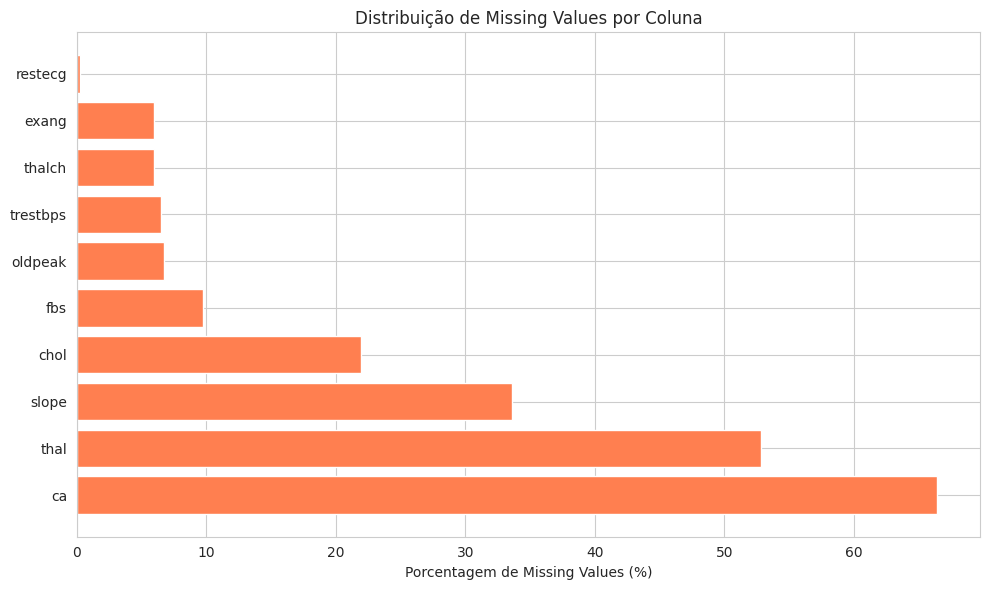

In [4]:
# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)
    
    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

### 3.2 Análise da Variável Target

**Objetivo:** Entender a distribuição da variável alvo (balanceamento de classes)

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
0    411
1    509
Name: count, dtype: int64

Percentual:
Sem doença (0): 44.67%
Com doença (1): 55.33%


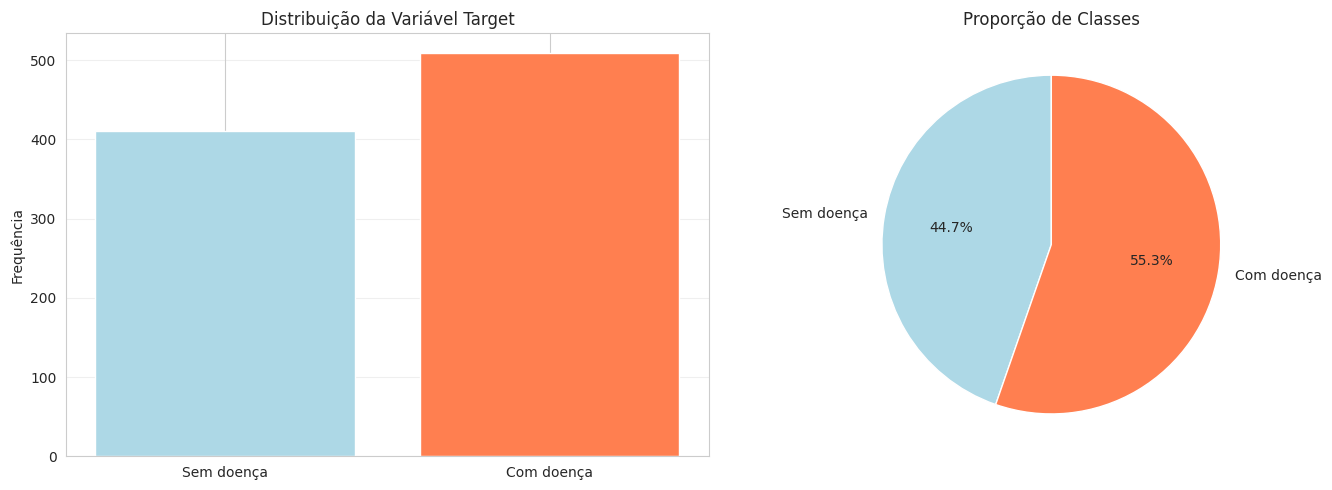


Ratio de balanceamento: 0.81
✓ Dataset razoavelmente balanceado.


In [5]:
# Renomear variável `num` para `target`
df.rename(columns={'num': 'target'}, inplace=True)

# Converter target para binário (0 = sem doença, 1 = com doença)
# No dataset original, valores > 0 indicam presença de doença
df['target'] = (df['target'] > 0).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
# Reindexar explicitamente evita associar as contagens aos rótulos errados:
# value_counts() ordena por frequência, não pelo valor da classe.
class_order = [0, 1]
class_labels = ['Sem doença', 'Com doença']
target_counts = df['target'].value_counts().reindex(class_order, fill_value=0)
target_percentages = (
    df['target'].value_counts(normalize=True).reindex(class_order, fill_value=0) * 100
)

print("Contagem:")
print(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Sem doença" if idx == 0 else "Com doença"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(class_labels, target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=class_labels, 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")

A variável alvo (target) indica se há presença (1) ou ausência (0) de doença cardíaca. Na visualização, vemos 509 casos “com doença” (55,3%) e 411 “sem doença” (44,7%), o que mostra uma leve predominância da classe positiva; o ratio entre as classes é de aproximadamente 0,81, indicando um desbalanceamento pequeno. Isso significa que podemos seguir com modelos base sem grandes ajustes, mas é importante acompanhar métricas além da acurácia, como F1, precisão e recall, e observar a matriz de confusão para entender os erros. Para manter a proporção das classes nas amostras, use divisão estratificada; se necessário, técnicas como class_weight ou SMOTE podem ser testadas, embora aqui sejam opcionais.

### 3.3 Análise de Outliers

**Objetivo:** Identificar valores extremos que podem ser erros de medição ou casos especiais

**Métodos utilizados:**
- **Z-Score**: Identifica valores que estão a mais de 3 desvios padrão da média
- **Visualização**: Boxplots para identificação visual

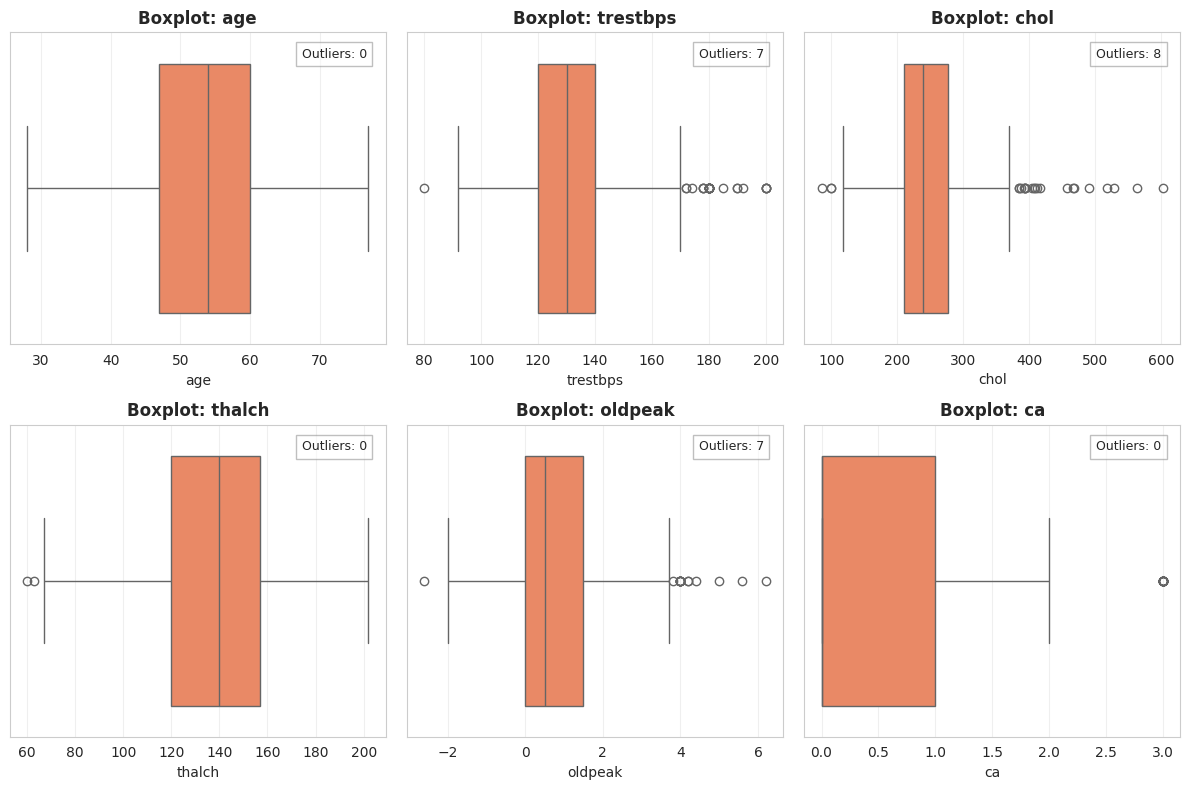

In [6]:
# Colunas numéricas (excluindo id e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['id', 'target'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


### Interpretação dos Resultados: Outliers via Z-Score e Boxplot

- **Boxplot:** destaca observações afastadas dos quartis, mas um ponto fora dos limites não é necessariamente um erro.
- **Z-Score:** mede a distância em relação à média em unidades de desvio padrão. O limite de 3 é uma heurística e é sensível à assimetria da distribuição.
- **Variáveis discretas:** em colunas como `ca`, boxplot e Z-Score têm interpretação limitada; tabelas de frequência são mais adequadas.

**Conclusão:**  
Esses diagnósticos identificam valores que merecem investigação, mas não permitem concluir que os dados seguem uma distribuição normal ou que estão “bem distribuídos”. Antes de aplicar remoção ou *capping*, é necessário distinguir erros de registro de casos clínicos legítimos e avaliar o impacto da decisão no modelo.


### 3.4 Análise de Anomalias e Valores Inválidos

**Objetivo:** Identificar valores que não fazem sentido no contexto médico/clínico

In [7]:
print("=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===\n")

# Verificações de consistência baseadas em conhecimento de domínio
anomalies = []

# 1. Idade (deve estar entre 0 e 120)
age_anomalies = df[(df['age'] < 0) | (df['age'] > 120)]
if len(age_anomalies) > 0:
    anomalies.append(f"Idade fora do intervalo válido: {len(age_anomalies)} casos")
    
# 2. Pressão arterial (trestbps) - valores típicos: 80-200 mmHg
bp_anomalies = df[(df['trestbps'] < 80) | (df['trestbps'] > 200)]
if len(bp_anomalies) > 0:
    anomalies.append(f"Pressão arterial anormal: {len(bp_anomalies)} casos")
    print(f"⚠️ Pressão arterial anormal detectada: {len(bp_anomalies)} casos")
    print(f"   Valores: min={df['trestbps'].min()}, max={df['trestbps'].max()}")

# 3. Colesterol (chol) - valores típicos: 100-400 mg/dl
chol_anomalies = df[(df['chol'] < 100) | (df['chol'] > 400)]
if len(chol_anomalies) > 0:
    anomalies.append(f"Colesterol anormal: {len(chol_anomalies)} casos")
    print(f"⚠️ Colesterol anormal detectado: {len(chol_anomalies)} casos")
    print(f"   Valores: min={df['chol'].min()}, max={df['chol'].max()}")

# 4. Frequência cardíaca máxima (thalch) - valores típicos: 60-220 bpm
hr_anomalies = df[(df['thalch'] < 60) | (df['thalch'] > 220)]
if len(hr_anomalies) > 0:
    anomalies.append(f"Frequência cardíaca anormal: {len(hr_anomalies)} casos")
    print(f"⚠️ Frequência cardíaca anormal detectada: {len(hr_anomalies)} casos")
    print(f"   Valores: min={df['thalch'].min()}, max={df['thalch'].max()}")

# 5. Variáveis categóricas com valores fora do esperado
# Nesta etapa, as colunas ainda possuem a representação original do CSV;
# o one-hot encoding será aplicado somente na preparação dos dados.
categorical_checks = {
    'sex': ['Female', 'Male'],
    'cp': ['typical angina', 'atypical angina', 'non-anginal', 'asymptomatic'],
    'fbs': [False, True],
    'restecg': ['normal', 'st-t abnormality', 'lv hypertrophy'],
    'exang': [False, True],
    'slope': ['upsloping', 'flat', 'downsloping'],
    'ca': [0, 1, 2, 3],
    'thal': ['normal', 'fixed defect', 'reversable defect']
}

for col, valid_values in categorical_checks.items():
    if col in df.columns:
        invalid = df[~df[col].isin(valid_values) & df[col].notna()]
        if len(invalid) > 0:
            anomalies.append(f"{col}: {len(invalid)} valores inválidos")
            print(f"⚠️ {col}: {len(invalid)} valores fora do domínio esperado {valid_values}")

if len(anomalies) == 0:
    print("✓ Nenhuma anomalia óbvia detectada nas validações de domínio!")
else:
    print(f"\n📊 Total de tipos de anomalias detectadas: {len(anomalies)}")

# Verificar duplicados
duplicates = df.duplicated().sum()
print(f"\n=== DUPLICADOS ===")
print(f"Registros duplicados: {duplicates}")
if duplicates > 0:
    print("⚠️ Considere remover ou investigar registros duplicados")

=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===

⚠️ Colesterol anormal detectado: 14 casos
   Valores: min=85.0, max=603.0

📊 Total de tipos de anomalias detectadas: 1

=== DUPLICADOS ===
Registros duplicados: 0


### 3.5 Análise de Distribuições

**Objetivo:** Avaliar separadamente as variáveis numéricas contínuas e discretas, descrevendo assimetria e excesso de curtose sem inferir normalidade apenas por essas estatísticas.

=== VARIÁVEIS NUMÉRICAS CONTÍNUAS ===

  Coluna   N  Assimetria   Interpretação da assimetria  Curtose (Fisher)           Interpretação da curtose
     age 920      -0.196     Aproximadamente simétrica            -0.383      Próxima de zero (mesocúrtica)
trestbps 860       0.630 Assimetria moderada à direita             0.631 Caudas mais pesadas (leptocúrtica)
    chol 718       1.315    Assimetria forte à direita             4.773 Caudas mais pesadas (leptocúrtica)
  thalch 865      -0.211     Aproximadamente simétrica            -0.480      Próxima de zero (mesocúrtica)
 oldpeak 858       1.041    Assimetria forte à direita             1.127 Caudas mais pesadas (leptocúrtica)


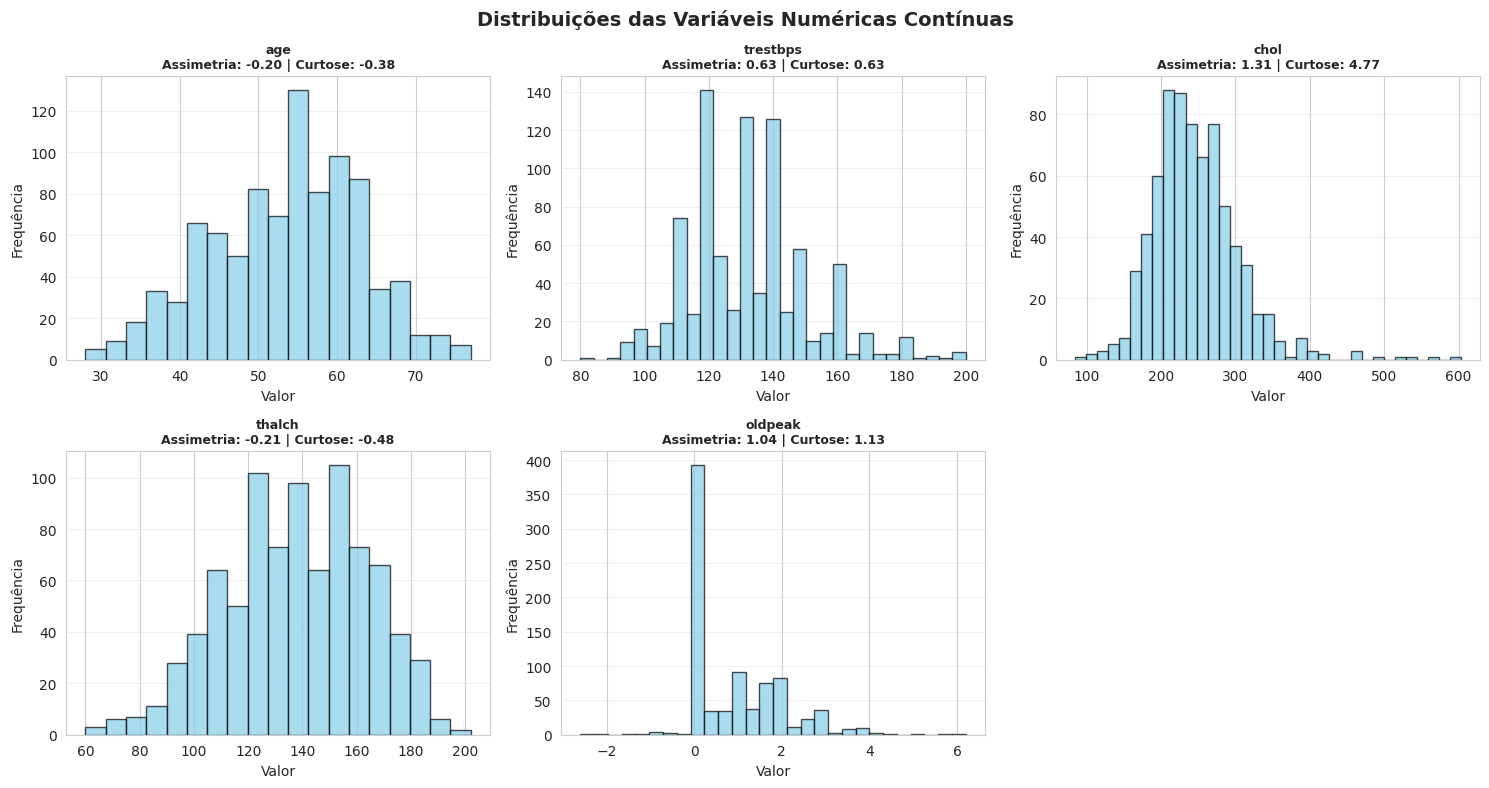


=== VARIÁVEIS NUMÉRICAS DISCRETAS ===

ca:
Categoria  Frequência  Percentual
        0         181       19.67
        1          67        7.28
        2          41        4.46
        3          20        2.17
  Ausente         611       66.41



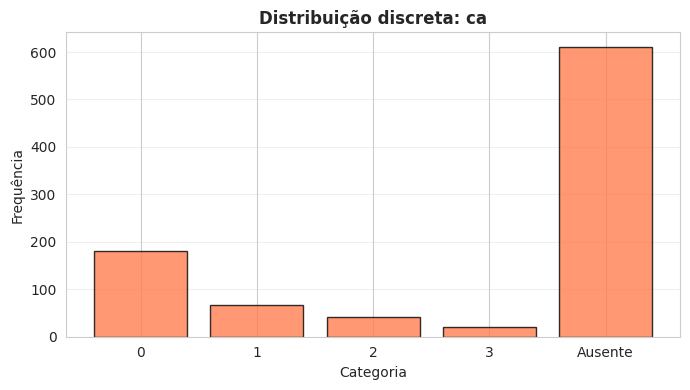

In [8]:
# Separar variáveis contínuas das numéricas discretas
continuous_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
discrete_cols = ['ca']


def interpret_skewness(value):
    """Classificação descritiva baseada em limites heurísticos."""
    if abs(value) < 0.5:
        return 'Aproximadamente simétrica'

    direction = 'à direita' if value > 0 else 'à esquerda'
    intensity = 'moderada' if abs(value) < 1 else 'forte'
    return f'Assimetria {intensity} {direction}'


def interpret_kurtosis(value):
    """Interpreta o excesso de curtose de Fisher, cujo valor normal é zero."""
    if abs(value) < 0.5:
        return 'Próxima de zero (mesocúrtica)'
    if value > 0:
        return 'Caudas mais pesadas (leptocúrtica)'
    return 'Caudas mais leves (platicúrtica)'


print("=== VARIÁVEIS NUMÉRICAS CONTÍNUAS ===\n")

distribution_stats = []
for col in continuous_cols:
    values = df[col].dropna()
    skewness = values.skew()
    kurtosis = values.kurtosis()  # Excesso de curtose de Fisher: normal = 0
    distribution_stats.append({
        'Coluna': col,
        'N': len(values),
        'Assimetria': round(skewness, 3),
        'Interpretação da assimetria': interpret_skewness(skewness),
        'Curtose (Fisher)': round(kurtosis, 3),
        'Interpretação da curtose': interpret_kurtosis(kurtosis)
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Histogramas apenas para variáveis contínuas
ncols = 3
nrows = int(np.ceil(len(continuous_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.atleast_1d(axes).ravel()

for idx, col in enumerate(continuous_cols):
    values = df[col].dropna()
    axes[idx].hist(values, bins='auto', color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(
        f'{col}\nAssimetria: {values.skew():.2f} | Curtose: {values.kurtosis():.2f}',
        fontsize=9, fontweight='bold'
    )
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frequência')
    axes[idx].grid(axis='y', alpha=0.3)

for ax in axes[len(continuous_cols):]:
    fig.delaxes(ax)

plt.suptitle('Distribuições das Variáveis Numéricas Contínuas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Variáveis discretas são descritas por frequências, sem medidas de forma contínua
print("\n=== VARIÁVEIS NUMÉRICAS DISCRETAS ===\n")

fig, axes = plt.subplots(1, len(discrete_cols), figsize=(7 * len(discrete_cols), 4))
axes = np.atleast_1d(axes)

for idx, col in enumerate(discrete_cols):
    plot_values = df[col].map(
        lambda value: 'Ausente' if pd.isna(value) else str(int(value))
    )
    order = [str(int(value)) for value in sorted(df[col].dropna().unique())]
    if df[col].isna().any():
        order.append('Ausente')

    counts = plot_values.value_counts().reindex(order, fill_value=0)
    frequency_table = pd.DataFrame({
        'Categoria': counts.index,
        'Frequência': counts.values,
        'Percentual': (counts.values / len(df) * 100).round(2)
    })
    print(f'{col}:')
    print(frequency_table.to_string(index=False))
    print()

    axes[idx].bar(counts.index, counts.values, color='coral', edgecolor='black', alpha=0.8)
    axes[idx].set_title(f'Distribuição discreta: {col}', fontweight='bold')
    axes[idx].set_xlabel('Categoria')
    axes[idx].set_ylabel('Frequência')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Como interpretar esta análise

- **Assimetria:** valores próximos de zero indicam simetria aproximada, não normalidade. Os limites 0,5 e 1 são heurísticos para descrever intensidade.
- **Curtose:** o pandas calcula o excesso de curtose de Fisher. Valor próximo de zero é compatível com a curtose da distribuição normal; valores positivos indicam caudas mais pesadas e valores negativos, caudas mais leves.
- **Valores ausentes:** as estatísticas ignoram `NaN`; por isso, a coluna `N` deve ser considerada na comparação entre variáveis.
- **Variáveis discretas:** `ca` é apresentada por frequências porque assimetria, curtose e histogramas contínuos têm interpretação limitada para poucos níveis inteiros.

> Assimetria e curtose são medidas descritivas e não constituem, isoladamente, um teste de normalidade. A regressão logística também não exige normalidade das variáveis explicativas. Possíveis transformações devem ser avaliadas dentro do pipeline e comparadas por validação cruzada.

### 3.6 Análise de Correlações

**Objetivo:** Identificar relações entre variáveis e detectar multicolinearidade

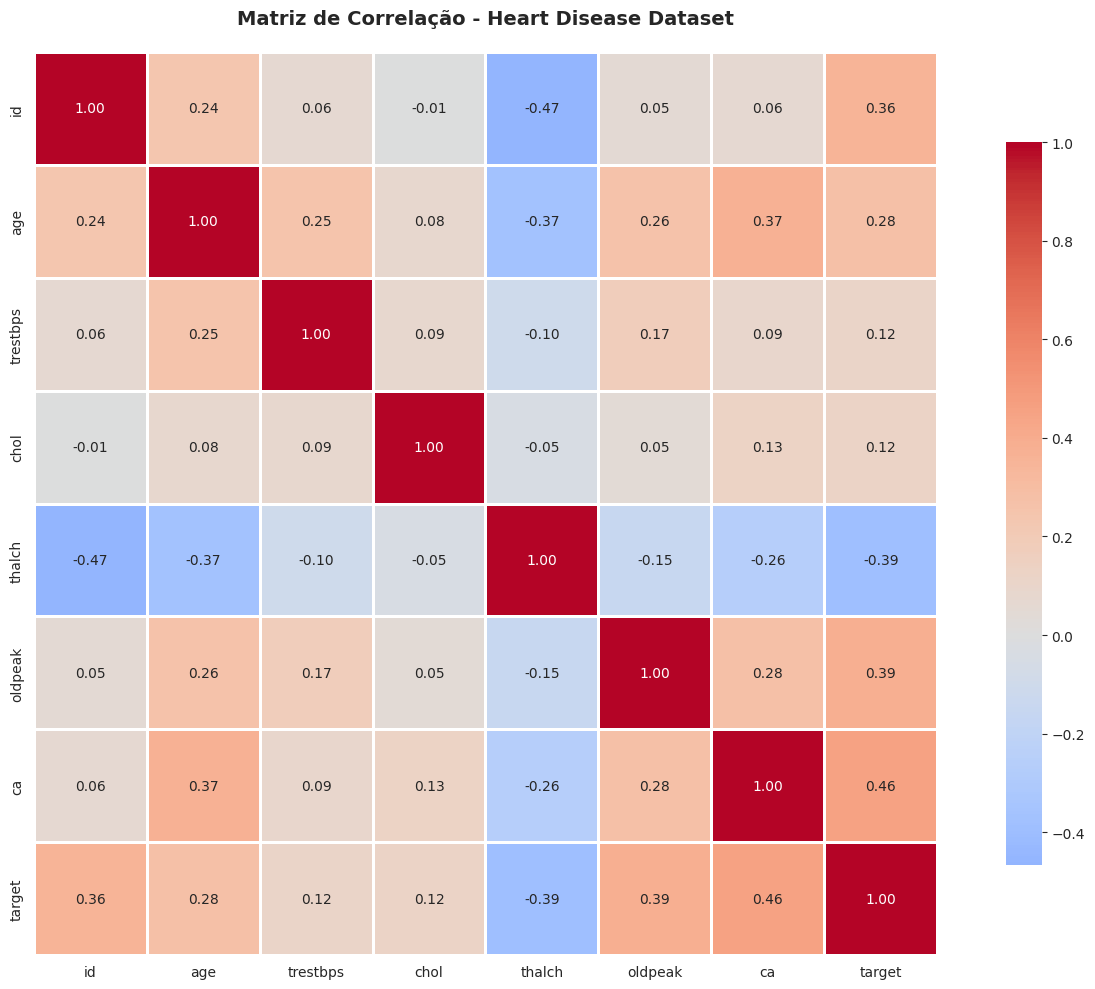

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

target      1.000000
ca          0.455599
oldpeak     0.385528
id          0.356086
age         0.282700
chol        0.118327
trestbps    0.116959
thalch     -0.394503
Name: target, dtype: float64

=== MULTICOLINEARIDADE (Correlação entre features) ===
Pares de features com correlação > 0.7:

✓ Nenhuma correlação forte detectada entre features (excluindo target)


In [9]:
# Matriz de correlação apenas para colunas numéricas
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Heart Disease Dataset', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr)

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlação': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features (excluindo target)")

## 4. Preparação dos Dados

### 4.1 Separação de treino e teste

A divisão é realizada **uma única vez**, antes de qualquer transformação que aprenda estatísticas dos dados. O parâmetro `stratify=y` preserva a proporção das classes, enquanto `dataset` é mantido separadamente para avaliar o desempenho por centro clínico.

> O conjunto de teste será utilizado somente na avaliação final. Imputação, codificação, escalonamento e validação cruzada serão ajustados exclusivamente com os dados de treino.

In [10]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20

zero_missing_numeric_cols = ['trestbps', 'chol']
continuous_numeric_cols = ['age', 'thalch', 'oldpeak']
discrete_cols = ['ca']
boolean_cols = ['fbs', 'exang']
categorical_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
feature_cols = (
    zero_missing_numeric_cols
    + continuous_numeric_cols
    + discrete_cols
    + boolean_cols
    + categorical_cols
)

X = df[feature_cols].copy()
numeric_feature_cols = (
    zero_missing_numeric_cols + continuous_numeric_cols + discrete_cols
)
# Um schema numérico uniforme evita ambiguidades de tipos na assinatura MLflow.
X[numeric_feature_cols] = X[numeric_feature_cols].astype(float)
y = df['target'].copy()
groups = df['dataset'].copy()

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

split_summary = pd.DataFrame({
    'Conjunto': ['Completo', 'Treino', 'Teste'],
    'Observações': [len(y), len(y_train), len(y_test)],
    'Taxa positiva (%)': [y.mean() * 100, y_train.mean() * 100, y_test.mean() * 100]
})
print(split_summary.round(2).to_string(index=False))

print("\nObservações por centro clínico:")
site_split_summary = pd.crosstab(
    groups,
    pd.Series(
        np.where(groups.index.isin(X_test.index), 'Teste', 'Treino'),
        index=groups.index,
        name='Conjunto'
    )
)
print(site_split_summary.to_string())

Conjunto  Observações  Taxa positiva (%)
Completo          920              55.33
  Treino          736              55.30
   Teste          184              55.43

Observações por centro clínico:
Conjunto       Teste  Treino
dataset                     
Cleveland         55     249
Hungary           64     229
Switzerland       28      95
VA Long Beach     37     163


### 4.2 Pipeline de pré-processamento

O `ColumnTransformer` aplica uma estratégia adequada a cada tipo de variável e aprende todos os parâmetros somente durante `fit()`:

- zeros sentinela e ausências em `trestbps`/`chol`: mediana + indicador de ausência;
- demais contínuas: mediana + indicador de ausência + `StandardScaler`;
- `ca`: categoria própria para ausência e One-hot Encoding;
- booleanas: moda + indicador de ausência + One-hot Encoding;
- categóricas textuais: categoria `missing` + One-hot Encoding com categorias desconhecidas ignoradas.

O estimador fica no mesmo `Pipeline`, garantindo que treinamento, validação e inferência executem exatamente as mesmas transformações. São criadas duas variantes:

- **Completa:** utiliza todas as features, incluindo `ca` e `thal`;
- **Reduzida:** remove somente `ca` e `thal`, mantendo todo o restante idêntico para realizar uma ablação¹ justa.

> ¹ **Ablação:** experimento controlado em que um componente — neste caso, as variáveis `ca` e `thal` — é removido enquanto todo o restante permanece igual. A diferença entre os resultados ajuda a medir a contribuição desse componente.

In [11]:
from IPython.display import Markdown, display
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

def build_model_pipeline(include_ca=True, include_thal=True):
    """Cria pipelines comparáveis, variando somente ca e thal."""
    zero_missing_pipeline = Pipeline([
        # Trata de forma uniforme NaN e zeros sentinela recebidos na inferência.
        ('nan_to_zero', FunctionTransformer(
            np.nan_to_num, kw_args={'nan': 0.0}, feature_names_out='one-to-one'
        )),
        ('imputer', SimpleImputer(
            missing_values=0, strategy='median', add_indicator=True
        )),
        ('scaler', StandardScaler())
    ])

    continuous_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler())
    ])

    boolean_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent', add_indicator=True)),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore', drop='if_binary', sparse_output=False
        ))
    ])

    selected_categorical_cols = [
        col for col in categorical_cols if include_thal or col != 'thal'
    ]
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    transformers = [
        ('zero_missing_numeric', zero_missing_pipeline, zero_missing_numeric_cols),
        ('continuous_numeric', continuous_pipeline, continuous_numeric_cols),
        ('boolean', boolean_pipeline, boolean_cols),
        ('categorical', categorical_pipeline, selected_categorical_cols)
    ]

    if include_ca:
        discrete_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
        transformers.insert(2, ('discrete', discrete_pipeline, discrete_cols))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop',
        verbose_feature_names_out=False
    ).set_output(transform='pandas')

    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ])


reduced_feature_cols = [col for col in feature_cols if col not in ['ca', 'thal']]
model_candidates = {
    'full': {
        'label': 'Completo (com ca e thal)',
        'pipeline': build_model_pipeline(include_ca=True, include_thal=True),
        'features': feature_cols
    },
    'reduced': {
        'label': 'Reduzido (sem ca e thal)',
        'pipeline': build_model_pipeline(include_ca=False, include_thal=False),
        'features': reduced_feature_cols
    }
}

# Alias preservado para as células que tratam o modelo completo como baseline.
model_pipeline = model_candidates['full']['pipeline']
reduced_model_pipeline = model_candidates['reduced']['pipeline']

model_summary = pd.DataFrame([
    {'Modelo': config['label'], 'Número de features brutas': len(config['features'])}
    for config in model_candidates.values()
])

set_config(display='diagram')
display(model_summary)
display(Markdown('#### Pipeline completo (com `ca` e `thal`)'))
display(model_pipeline)
display(Markdown('#### Pipeline reduzido (sem `ca` e `thal`)'))
display(reduced_model_pipeline)

,Modelo,Número de features brutas
0,Completo (com ca e thal),13
1,Reduzido (sem ca e thal),11


#### Pipeline completo (com `ca` e `thal`)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('zero_missing_numeric', ...), ('continuous_numeric', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Pipeline reduzido (sem `ca` e `thal`)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('zero_missing_numeric', ...), ('continuous_numeric', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


## 5. Experimentação e MVP (Minimum Viable Product)

### Experimento: Regressão Logística (Baseline)

Primeiro, os pipelines completo e reduzido são avaliados somente no conjunto de treino, usando os mesmos folds e duas estratégias complementares:

1. `StratifiedKFold`: estima desempenho médio e variabilidade mantendo a proporção das classes;
2. `LeaveOneGroupOut`: mantém um centro clínico inteiro fora do treino em cada rodada, oferecendo uma estimativa mais exigente de generalização entre centros.

O conjunto de teste permanece intocado até a célula seguinte.

In [12]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, make_scorer
)
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, cross_validate


def classification_metrics(y_true, y_pred, y_proba):
    """Calcula métricas globais com tratamento explícito das duas classes."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall_sensitivity': recall_score(y_true, y_pred, zero_division=0),
        'specificity': specificity,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'average_precision': average_precision_score(y_true, y_proba),
        'brier_score': brier_score_loss(y_true, y_proba)
    }


scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall_sensitivity': 'recall',
    'specificity': make_scorer(recall_score, pos_label=0),
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision'
}

stratified_cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)
cv_results_by_model = {}
cv_rows = []

for model_key, config in model_candidates.items():
    candidate_features = config['features']
    candidate_results = cross_validate(
        config['pipeline'],
        X_train[candidate_features],
        y_train,
        cv=stratified_cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    cv_results_by_model[model_key] = candidate_results

    for metric_name in scoring:
        cv_rows.append({
            'model_key': model_key,
            'Modelo': config['label'],
            'Métrica': metric_name,
            'Média': candidate_results[f'test_{metric_name}'].mean(),
            'Desvio padrão': candidate_results[f'test_{metric_name}'].std()
        })

cv_summary = pd.DataFrame(cv_rows)
print("=== VALIDAÇÃO CRUZADA ESTRATIFICADA (TREINO) ===")
print(
    cv_summary.drop(columns='model_key').round(4).to_string(index=False)
)

# Validação mais exigente: cada centro clínico é mantido fora do treino uma vez.
logo = LeaveOneGroupOut()
site_validation_rows = []

for model_key, config in model_candidates.items():
    candidate_features = config['features']
    X_train_candidate = X_train[candidate_features]

    for train_idx, validation_idx in logo.split(
        X_train_candidate, y_train, groups_train
    ):
        site_model = clone(config['pipeline'])
        site_model.fit(
            X_train_candidate.iloc[train_idx], y_train.iloc[train_idx]
        )

        X_validation = X_train_candidate.iloc[validation_idx]
        y_validation = y_train.iloc[validation_idx]
        y_validation_pred = site_model.predict(X_validation)
        y_validation_proba = site_model.predict_proba(X_validation)[:, 1]
        site_name = groups_train.iloc[validation_idx].iloc[0]

        row = {
            'model_key': model_key,
            'Modelo': config['label'],
            'dataset': site_name,
            'n': len(validation_idx),
            'positive_rate': y_validation.mean()
        }
        row.update(classification_metrics(
            y_validation, y_validation_pred, y_validation_proba
        ))
        site_validation_rows.append(row)

site_validation_df = pd.DataFrame(site_validation_rows).sort_values(
    ['dataset', 'model_key']
)
print("\n=== LEAVE-ONE-DATASET-OUT (TREINO) ===")
print(
    site_validation_df.drop(columns='model_key').round(4).to_string(index=False)
)

=== VALIDAÇÃO CRUZADA ESTRATIFICADA (TREINO) ===
                  Modelo            Métrica  Média  Desvio padrão
Completo (com ca e thal)           accuracy 0.8139         0.0209
Completo (com ca e thal)          precision 0.8275         0.0407
Completo (com ca e thal) recall_sensitivity 0.8426         0.0205
Completo (com ca e thal)        specificity 0.7780         0.0673
Completo (com ca e thal)                 f1 0.8340         0.0133
Completo (com ca e thal)            roc_auc 0.8964         0.0214
Completo (com ca e thal)  average_precision 0.9097         0.0203
Reduzido (sem ca e thal)           accuracy 0.8017         0.0268
Reduzido (sem ca e thal)          precision 0.8189         0.0408
Reduzido (sem ca e thal) recall_sensitivity 0.8279         0.0318
Reduzido (sem ca e thal)        specificity 0.7687         0.0700
Reduzido (sem ca e thal)                 f1 0.8222         0.0209
Reduzido (sem ca e thal)            roc_auc 0.8813         0.0273
Reduzido (sem ca e thal)  a

=== COMPARAÇÃO FINAL — TESTE INTOCADO ===
                  Modelo  n_features_brutas  train_accuracy  generalization_gap  solver_iterations  accuracy  precision  recall_sensitivity  specificity     f1  roc_auc  average_precision  brier_score
Completo (com ca e thal)                 13          0.8356             -0.0231                 28    0.8587     0.8585              0.8922       0.8171 0.8750   0.9219             0.9239       0.1078
Reduzido (sem ca e thal)                 11          0.8139             -0.0340                 37    0.8478     0.8426              0.8922       0.7927 0.8667   0.9119             0.9152       0.1145

=== RESULTADOS POR CENTRO — TESTE ===
                  Modelo       dataset  n  positive_rate  accuracy  precision  recall_sensitivity  specificity     f1  roc_auc  average_precision  brier_score
Completo (com ca e thal)     Cleveland 55         0.4727    0.8545     0.8000              0.9231       0.7931 0.8571   0.9456             0.9451       0.101

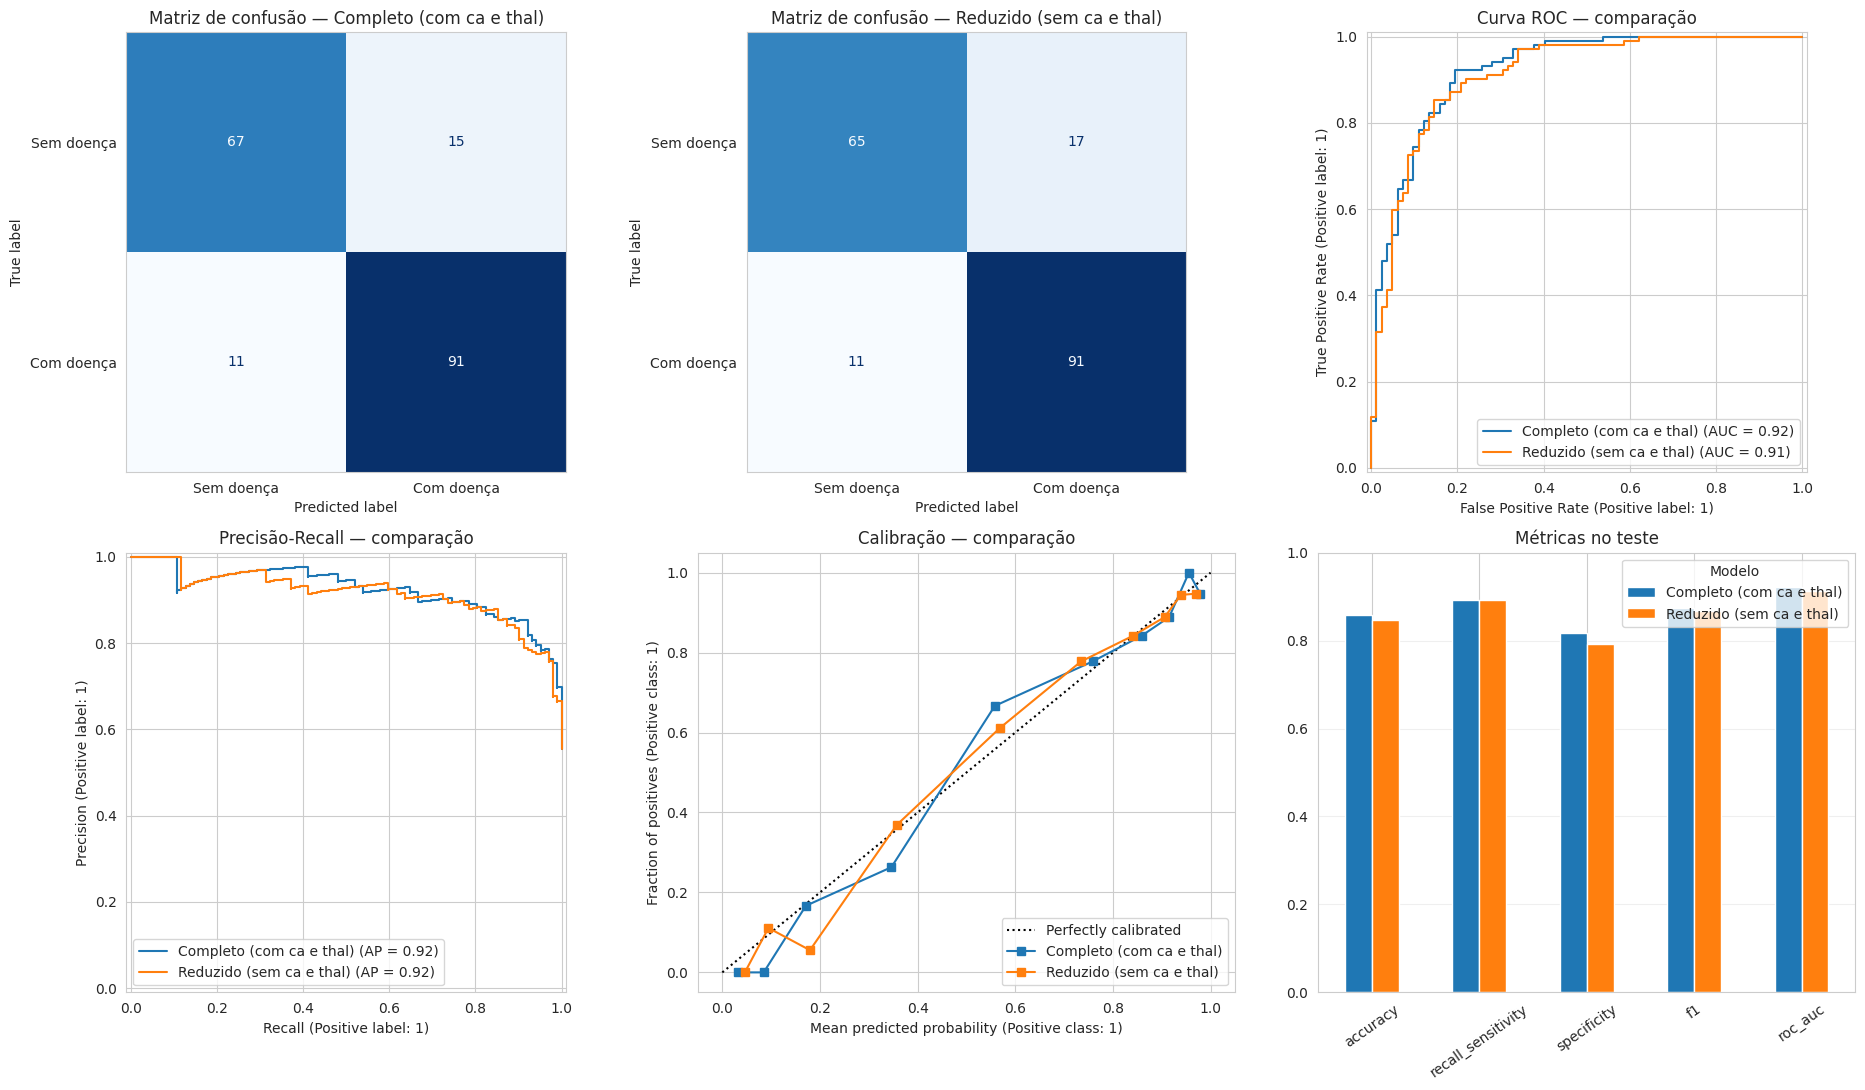

In [13]:
from hashlib import sha256
from pathlib import Path

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
)

# Tipos conhecidos e usados explicitamente pelo pipeline. O MLflow/skops
# continuará rejeitando qualquer outro tipo não confiável na serialização.
SKOPS_TRUSTED_TYPES = ['numpy.dtype', 'numpy.nan_to_num']

# URI explícita evita que o destino dos runs dependa do diretório de execução.
tracking_db = Path('mlflow.db').resolve()
mlflow.set_tracking_uri(f'sqlite:///{tracking_db}')
mlflow.set_experiment('heart_disease_classification')

# Ajustar e avaliar as duas variantes no mesmo conjunto de teste intocado.
fitted_models = {}
test_predictions_by_model = {}
test_metric_rows = []
site_test_rows = []

for model_key, config in model_candidates.items():
    candidate_features = config['features']
    candidate_model = clone(config['pipeline'])
    candidate_model.fit(X_train[candidate_features], y_train)

    y_train_pred = candidate_model.predict(X_train[candidate_features])
    y_test_pred = candidate_model.predict(X_test[candidate_features])
    y_test_proba = candidate_model.predict_proba(X_test[candidate_features])[:, 1]
    candidate_metrics = classification_metrics(y_test, y_test_pred, y_test_proba)
    train_accuracy = accuracy_score(y_train, y_train_pred)

    fitted_models[model_key] = candidate_model
    test_predictions_by_model[model_key] = {
        'prediction': y_test_pred,
        'probability': y_test_proba
    }
    test_metric_rows.append({
        'model_key': model_key,
        'Modelo': config['label'],
        'n_features_brutas': len(candidate_features),
        'train_accuracy': train_accuracy,
        'generalization_gap': train_accuracy - candidate_metrics['accuracy'],
        'solver_iterations': candidate_model.named_steps['classifier'].n_iter_[0],
        **candidate_metrics
    })

    test_predictions = pd.DataFrame({
        'dataset': groups_test,
        'target': y_test,
        'prediction': y_test_pred,
        'probability': y_test_proba
    }, index=y_test.index)

    for site_name, site_data in test_predictions.groupby('dataset'):
        row = {
            'model_key': model_key,
            'Modelo': config['label'],
            'dataset': site_name,
            'n': len(site_data),
            'positive_rate': site_data['target'].mean()
        }
        row.update(classification_metrics(
            site_data['target'],
            site_data['prediction'],
            site_data['probability']
        ))
        site_test_rows.append(row)

comparison_df = pd.DataFrame(test_metric_rows).sort_values('model_key')
site_test_df = pd.DataFrame(site_test_rows).sort_values(
    ['dataset', 'model_key']
)

# Manter aliases explícitos para persistência e uso posterior.
model_pipeline = fitted_models['full']
reduced_model_pipeline = fitted_models['reduced']

# Sensibilidade específica: chol está 100% ausente em Switzerland.
# O contrafactual abaixo mantém o valor numérico na mediana imputada e muda
# apenas o indicador de ausência. Não deve ser interpretado causalmente.
switzerland_mask = groups_test.eq('Switzerland')
chol_train_median = X_train['chol'].median()
switzerland_chol_rows = []

for model_key, config in model_candidates.items():
    candidate_features = config['features']
    candidate_model = fitted_models[model_key]
    X_switzerland = X_test.loc[switzerland_mask, candidate_features].copy()
    original_proba = candidate_model.predict_proba(X_switzerland)[:, 1]

    X_switzerland_counterfactual = X_switzerland.copy()
    X_switzerland_counterfactual['chol'] = chol_train_median
    counterfactual_proba = candidate_model.predict_proba(
        X_switzerland_counterfactual
    )[:, 1]
    probability_delta = original_proba - counterfactual_proba

    feature_names = candidate_model.named_steps[
        'preprocessor'
    ].get_feature_names_out()
    coefficients = candidate_model.named_steps['classifier'].coef_[0]
    coefficient_map = dict(zip(feature_names, coefficients))

    switzerland_chol_rows.append({
        'model_key': model_key,
        'Modelo': config['label'],
        'n_switzerland_test': len(X_switzerland),
        'chol_missing_pct': X_switzerland['chol'].isna().mean() * 100,
        'chol_train_median': chol_train_median,
        'chol_missing_indicator_coef': coefficient_map.get(
            'missingindicator_chol', np.nan
        ),
        'mean_probability_missing': original_proba.mean(),
        'mean_probability_if_median_observed': counterfactual_proba.mean(),
        'mean_probability_delta': probability_delta.mean(),
        'max_absolute_probability_delta': np.abs(probability_delta).max(),
        'prediction_flips_at_0_5': int(np.sum(
            (original_proba >= 0.5) != (counterfactual_proba >= 0.5)
        ))
    })

switzerland_chol_sensitivity_df = pd.DataFrame(switzerland_chol_rows)

# Visualizações comparativas no mesmo holdout.
evaluation_fig, axes = plt.subplots(2, 3, figsize=(19, 11))
for axis, model_key in zip(axes[0, :2], ['full', 'reduced']):
    prediction_data = test_predictions_by_model[model_key]
    ConfusionMatrixDisplay.from_predictions(
        y_test, prediction_data['prediction'],
        display_labels=['Sem doença', 'Com doença'],
        cmap='Blues', ax=axis, colorbar=False
    )
    axis.set_title(f'Matriz de confusão — {model_candidates[model_key]["label"]}')
    # O estilo global whitegrid adiciona linhas sobre as células e os números.
    axis.grid(visible=False, which='both', axis='both')
    axis.minorticks_off()

for model_key, config in model_candidates.items():
    probabilities = test_predictions_by_model[model_key]['probability']
    RocCurveDisplay.from_predictions(
        y_test, probabilities, name=config['label'], ax=axes[0, 2]
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, probabilities, name=config['label'], ax=axes[1, 0]
    )
    CalibrationDisplay.from_predictions(
        y_test, probabilities, n_bins=10, strategy='quantile',
        name=config['label'], ax=axes[1, 1]
    )

axes[0, 2].set_title('Curva ROC — comparação')
axes[1, 0].set_title('Precisão-Recall — comparação')
axes[1, 1].set_title('Calibração — comparação')
comparison_df.set_index('Modelo')[
    ['accuracy', 'recall_sensitivity', 'specificity', 'f1', 'roc_auc']
].T.plot(kind='bar', ax=axes[1, 2])
axes[1, 2].set_title('Métricas no teste')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].tick_params(axis='x', rotation=35)
axes[1, 2].grid(axis='y', alpha=0.3)
evaluation_fig.tight_layout()

# Registrar um run por variante permite comparação direta na interface MLflow.
data_path = Path(path).resolve()
data_sha256 = sha256(data_path.read_bytes()).hexdigest()
run_ids = {}

for model_key, config in model_candidates.items():
    candidate_model = fitted_models[model_key]
    candidate_features = config['features']
    model_comparison_row = comparison_df[comparison_df['model_key'].eq(model_key)].iloc[0]
    model_cv_summary = cv_summary[cv_summary['model_key'].eq(model_key)]
    model_site_validation = site_validation_df[
        site_validation_df['model_key'].eq(model_key)
    ]
    model_site_test = site_test_df[site_test_df['model_key'].eq(model_key)]
    classifier_params = candidate_model.named_steps['classifier'].get_params()

    with mlflow.start_run(run_name=f'logistic_regression_{model_key}') as run:
        mlflow.log_params({
            'model_class': 'LogisticRegression',
            'model_variant': model_key,
            'feature_set': ','.join(candidate_features),
            'excluded_features': 'ca,thal' if model_key == 'reduced' else 'none',
            'test_size': TEST_SIZE,
            'random_state': RANDOM_STATE,
            'split_strategy': 'stratified_holdout',
            'cv_strategy': 'StratifiedKFold(n_splits=5)',
            'group_validation': 'LeaveOneGroupOut(dataset)',
            'classifier_C': classifier_params['C'],
            'classifier_solver': classifier_params['solver'],
            'classifier_max_iter': classifier_params['max_iter'],
            'data_sha256': data_sha256,
            'n_train': len(X_train),
            'n_test': len(X_test)
        })
        mlflow.set_tags({
            'task': 'binary_classification',
            'dataset': 'UCI Heart Disease consolidated',
            'model_scope': 'MVP feature ablation'
        })

        excluded_log_columns = {
            'model_key', 'Modelo', 'n_features_brutas', 'solver_iterations'
        }
        mlflow.log_metrics({
            f'test_{name}' if name not in ['train_accuracy', 'generalization_gap'] else name:
            float(value)
            for name, value in model_comparison_row.items()
            if name not in excluded_log_columns and pd.notna(value)
        })
        mlflow.log_metric(
            'solver_iterations', float(model_comparison_row['solver_iterations'])
        )

        for _, row in model_cv_summary.iterrows():
            metric_key = row['Métrica']
            mlflow.log_metric(f'cv_{metric_key}_mean', float(row['Média']))
            mlflow.log_metric(f'cv_{metric_key}_std', float(row['Desvio padrão']))

        mlflow.log_table(
            comparison_df, artifact_file='metrics/model_comparison.json'
        )
        mlflow.log_table(
            model_cv_summary, artifact_file='metrics/stratified_cv.json'
        )
        mlflow.log_table(
            model_site_validation,
            artifact_file='metrics/leave_one_dataset_out.json'
        )
        mlflow.log_table(
            model_site_test, artifact_file='metrics/test_by_dataset.json'
        )
        mlflow.log_table(
            switzerland_chol_sensitivity_df,
            artifact_file='metrics/switzerland_chol_sensitivity.json'
        )
        mlflow.log_figure(evaluation_fig, 'figures/model_comparison.png')

        input_example = X_train[candidate_features].head(5)
        signature = infer_signature(
            input_example, candidate_model.predict(input_example)
        )
        mlflow.sklearn.log_model(
            candidate_model,
            name='model',
            signature=signature,
            input_example=input_example,
            skops_trusted_types=SKOPS_TRUSTED_TYPES
        )
        run_ids[model_key] = run.info.run_id

print("=== COMPARAÇÃO FINAL — TESTE INTOCADO ===")
print(comparison_df.drop(columns='model_key').round(4).to_string(index=False))
print("\n=== RESULTADOS POR CENTRO — TESTE ===")
print(site_test_df.drop(columns='model_key').round(4).to_string(index=False))
print("\n=== SENSIBILIDADE À AUSÊNCIA DE CHOL — SWITZERLAND ===")
print(
    switzerland_chol_sensitivity_df.drop(columns='model_key')
    .round(4).to_string(index=False)
)
print(f'\nMLflow run_ids: {run_ids}')
plt.show()

### Considerações para decidir sobre `ca`, `thal` e `chol`

- A decisão entre os modelos deve priorizar a validação cruzada e o `LeaveOneGroupOut`, não uma pequena diferença no teste final.
- Se a variante reduzida mantiver desempenho semelhante e reduzir a variação entre centros, ela é preferível por usar features mais disponíveis e oferecer um contrato de entrada mais simples.
- Ganhos do modelo completo concentrados no split aleatório, sem melhora no leave-one-center-out, sugerem dependência do padrão de coleta de `ca` e `thal`.
- Se `ca` e `thal` estiverem garantidamente disponíveis no momento da predição e fizerem parte do mesmo fluxo clínico do treinamento, o modelo completo ainda pode ser apropriado.
- Em Switzerland, `chol` está 100% ausente. Portanto, o modelo não utiliza uma medição individual de colesterol nesses pacientes: utiliza a mediana do treino e o indicador de ausência. A análise contrafactual quantifica a influência desse indicador, mas não demonstra causalidade.
- Caso o indicador de ausência de `chol` altere muito as probabilidades, recomenda-se uma terceira ablação sem `chol` ou uma validação externa em um centro onde colesterol seja medido de forma consistente.

#### Leitura dos resultados obtidos (`random_state=42`)

- O modelo completo apresentou vantagem pequena, mas consistente: acurácia média de validação cruzada de aproximadamente 0,814 contra 0,802 e ROC-AUC de 0,896 contra 0,881. No teste, as acurácias foram 0,859 e 0,848, respectivamente.
- O recall no teste foi igual (0,892) e a especificidade caiu de 0,817 para 0,793 no modelo reduzido. Assim, esta ablação não oferece evidência de que remover `ca` e `thal` melhore o desempenho geral.
- No leave-one-center-out, a variante reduzida melhorou discretamente a acurácia em VA Long Beach, mas perdeu especificidade. Nos demais centros, o modelo completo foi igual ou superior. Não há ganho consistente de robustez entre centros.
- A variante reduzida continua sendo uma alternativa operacional razoável quando `ca` e `thal` não estiverem disponíveis: a perda global foi pequena e o contrato de entrada ficou mais simples. Se esses exames estiverem garantidos no momento da predição, os resultados favorecem manter o modelo completo.
- Em Switzerland, desligar apenas o indicador de ausência de `chol` reduziu a probabilidade média em cerca de 0,078 no modelo completo e 0,104 no reduzido, mudando 3 e 4 classificações entre 28 casos. Isso mostra dependência relevante do padrão de ausência, provavelmente associado ao centro e ao processo de coleta.
- As métricas de especificidade e ROC-AUC do teste suíço são instáveis porque existe apenas um caso negativo nesse subconjunto. A conclusão sobre `chol` deve se apoiar também na validação por centro e, idealmente, em validação externa.

## 6. Persistir dataset numérico para a Aula 3

A Aula 3 utiliza um CSV numérico para praticar engenharia e seleção de features. Esse artefato é gerado por um **transformador de compatibilidade separado**, ajustado somente no treino e sem escalonamento, para preservar o significado clínico de variáveis como colesterol e idade.

> Este CSV é um contrato didático entre aulas; ele não é a entrada do modelo da Aula 2. O modelo utiliza e persiste seu próprio pipeline completo.

In [14]:
# Pré-processador sem escalonamento para manter compatibilidade com a Aula 3.
compatibility_numeric_cols = (
    zero_missing_numeric_cols + continuous_numeric_cols + discrete_cols
)
compatibility_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', SimpleImputer(strategy='median'), compatibility_numeric_cols),
        ('boolean', SimpleImputer(strategy='most_frequent'), boolean_cols),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(
                handle_unknown='ignore', drop='first', sparse_output=False
            ))
        ]), categorical_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
).set_output(transform='pandas')

compatibility_preprocessor.fit(X_train)
df_encoded = compatibility_preprocessor.transform(X)
df_encoded.insert(0, 'id', df['id'].to_numpy())
df_encoded['target'] = y.to_numpy()

preprocessed_path = Path('../data/heart_disease_uci_preprocessed.csv').resolve()
df_encoded.to_csv(preprocessed_path, index=False)

print(f'Dataset numérico salvo em: {preprocessed_path}')
print(f'Shape: {df_encoded.shape}')
print(f'Valores ausentes: {int(df_encoded.isna().sum().sum())}')
df_encoded.head()

Dataset numérico salvo em: /home/carloslessa/FCD/POSTECH/modulo-extra/01-introducao-ciclo-de-vida-de-modelos/data/heart_disease_uci_preprocessed.csv
Shape: (920, 20)
Valores ausentes: 0


,id,trestbps,chol,age,thalch,oldpeak,ca,fbs,exang,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,target
0,1,145.0,233.0,63.0,150.0,2.3,0.0,True,False,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2,160.0,286.0,67.0,108.0,1.5,3.0,False,True,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1
2,3,120.0,229.0,67.0,129.0,2.6,2.0,False,True,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1
3,4,130.0,250.0,37.0,187.0,3.5,0.0,False,False,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
4,5,130.0,204.0,41.0,172.0,1.4,0.0,False,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0


## 7. Persistir os pipelines completos

Cada artefato contém imputação, codificação, escalonamento e classificador. `baseline_model.joblib` preserva o nome histórico para o modelo completo, enquanto `baseline_model_reduced.joblib` identifica explicitamente a variante sem `ca` e `thal`. Após salvar, o notebook recarrega ambos e compara predições para verificar a integridade da serialização.

In [15]:
import joblib

models_dir = Path('../models').resolve()
models_dir.mkdir(parents=True, exist_ok=True)
pipeline_paths = {
    'full': models_dir / 'baseline_model.joblib',
    'reduced': models_dir / 'baseline_model_reduced.joblib'
}

for model_key, pipeline_path in pipeline_paths.items():
    candidate_model = fitted_models[model_key]
    candidate_features = model_candidates[model_key]['features']

    joblib.dump(candidate_model, pipeline_path)
    reloaded_pipeline = joblib.load(pipeline_path)

    smoke_input = X_test[candidate_features].head(10)
    expected_predictions = candidate_model.predict(smoke_input)
    reloaded_predictions = reloaded_pipeline.predict(smoke_input)
    np.testing.assert_array_equal(expected_predictions, reloaded_predictions)

    print(f'{model_candidates[model_key]["label"]}: {pipeline_path}')
    print(f'  ✓ Smoke test concluído | MLflow run: {run_ids[model_key]}')

Completo (com ca e thal): /home/carloslessa/FCD/POSTECH/modulo-extra/01-introducao-ciclo-de-vida-de-modelos/models/baseline_model.joblib
  ✓ Smoke test concluído | MLflow run: d454604afc5e4244942923849c679b17
Reduzido (sem ca e thal): /home/carloslessa/FCD/POSTECH/modulo-extra/01-introducao-ciclo-de-vida-de-modelos/models/baseline_model_reduced.joblib
  ✓ Smoke test concluído | MLflow run: 5dd94a36582c42c5acf11bf0f44d1355
